# Hospital Readmissions Analysis

## Project Objective
Analyze hospital readmission data to identify patterns associated with readmission outcomes and support better healthcare quality improvement decisions.

## Tools Used
- Python
- pandas
- numpy
- matplotlib / seaborn
- Jupyter Notebook

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

## 2. Load Dataset

In [2]:
df = pd.read_csv("../data/hospital_readmissions.csv")

## 3. Initial Data Inspection

This section reviews the dataset structure, number of records, variables, data types, and missing values.

In [3]:
df.head()
df.shape
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 18330 entries, 0 to 18329
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Facility Name               18330 non-null  str    
 1   Facility ID                 18330 non-null  int64  
 2   State                       18330 non-null  str    
 3   Measure Name                18330 non-null  str    
 4   Number of Discharges        8242 non-null   float64
 5   Footnote                    6987 non-null   float64
 6   Excess Readmission Ratio    11720 non-null  float64
 7   Predicted Readmission Rate  11720 non-null  float64
 8   Expected Readmission Rate   11720 non-null  float64
 9   Number of Readmissions      11720 non-null  str    
 10  Start Date                  18330 non-null  str    
 11  End Date                    18330 non-null  str    
dtypes: float64(5), int64(1), str(6)
memory usage: 1.7 MB


In [4]:
df['Footnote'].unique()[:20]

array([nan,  5.,  1., 29.,  7.])

In [5]:
df['Footnote'].value_counts(dropna=False)

Footnote
NaN     11343
5.0      3255
1.0      3150
29.0      377
7.0       205
Name: count, dtype: int64

In [6]:
df.groupby('Footnote')['Excess Readmission Ratio'].count()

Footnote
1.0       0
5.0       0
7.0       0
29.0    377
Name: Excess Readmission Ratio, dtype: int64

In [7]:
df[df['Footnote'] == 29][[
    'Measure Name',
    'Excess Readmission Ratio',
    'Predicted Readmission Rate',
    'Expected Readmission Rate'
]].head(20)

,Measure Name,Excess Readmission Ratio,Predicted Readmission Rate,Expected Readmission Rate
30,READM-30-AMI-HRRP,0.9697,11.4644,11.8232
31,READM-30-CABG-HRRP,1.1213,12.5649,11.2054
32,READM-30-HF-HRRP,1.0373,19.9060,19.1894
34,READM-30-COPD-HRRP,0.9988,19.4501,19.4725
35,READM-30-PN-HRRP,1.0102,16.1282,15.9654
84,READM-30-PN-HRRP,0.8875,13.1459,14.8118
85,READM-30-HF-HRRP,1.0273,18.6111,18.1163
86,READM-30-COPD-HRRP,0.9239,16.2846,17.6261
87,READM-30-AMI-HRRP,1.0521,11.5674,10.9948
88,READM-30-CABG-HRRP,0.9704,9.9541,10.2577


## 4. Data Structure

In [8]:
df.columns
df.describe()
df.isnull().sum()

Facility Name                     0
Facility ID                       0
State                             0
Measure Name                      0
Number of Discharges          10088
Footnote                      11343
Excess Readmission Ratio       6610
Predicted Readmission Rate     6610
Expected Readmission Rate      6610
Number of Readmissions         6610
Start Date                        0
End Date                          0
dtype: int64

## 5. Clean column names

In [9]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
df.columns

Index(['facility_name', 'facility_id', 'state', 'measure_name',
       'number_of_discharges', 'footnote', 'excess_readmission_ratio',
       'predicted_readmission_rate', 'expected_readmission_rate',
       'number_of_readmissions', 'start_date', 'end_date'],
      dtype='str')

In [10]:
df['measure_name'].value_counts()
df['measure_name'].unique()

<StringArray>
['READM-30-HIP-KNEE-HRRP',     'READM-30-CABG-HRRP',      'READM-30-AMI-HRRP',
     'READM-30-COPD-HRRP',       'READM-30-PN-HRRP',       'READM-30-HF-HRRP']
Length: 6, dtype: str

In [11]:
df['measure_name'].value_counts()

measure_name
READM-30-HIP-KNEE-HRRP    3055
READM-30-CABG-HRRP        3055
READM-30-AMI-HRRP         3055
READM-30-COPD-HRRP        3055
READM-30-PN-HRRP          3055
READM-30-HF-HRRP          3055
Name: count, dtype: int64

In [12]:
df['excess_readmission_ratio'].describe()
df['predicted_readmission_rate'].describe()
df['expected_readmission_rate'].describe()

count    11720.000000
mean        14.947978
std          4.620865
min          3.087600
25%         12.623750
50%         15.856550
75%         18.500925
max         26.865400
Name: expected_readmission_rate, dtype: float64

## Create "Performance" variable

In [13]:
df['performance'] = np.where(
    df['excess_readmission_ratio'] > 1,
    'Above Expected',
    'Below Expected'
)

In [14]:
df['performance'].value_counts()

performance
Below Expected    12687
Above Expected     5643
Name: count, dtype: int64

## 5.Analysis

### 1st Chart "Hospital Performance Based on Readmission Ratio"

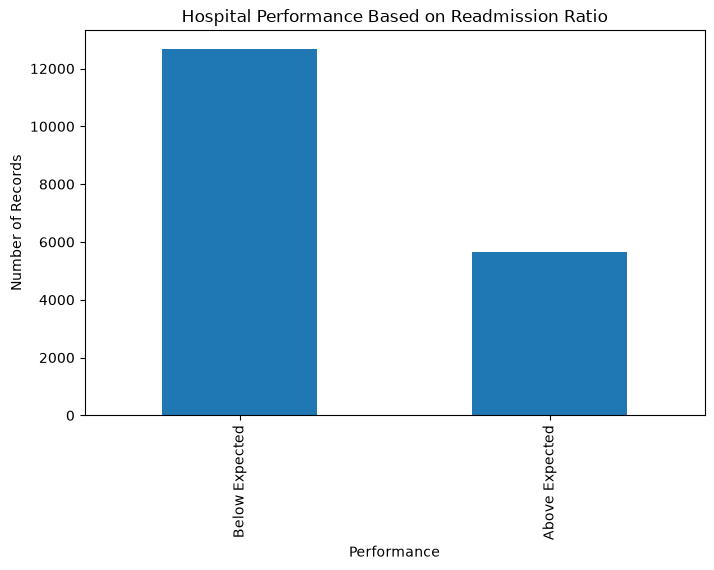

In [15]:
performance_counts = df['performance'].value_counts()

plt.figure(figsize=(8,5))

performance_counts.plot(kind='bar')

plt.title('Hospital Performance Based on Readmission Ratio')
plt.xlabel('Performance')
plt.ylabel('Number of Records')

plt.show()

### 2nd Chart
Calculate the average ERR by measure to determine which disease type has the highest ERR.

In [16]:
measure_err = (
    df.groupby('measure_name')['excess_readmission_ratio']
      .mean()
      .sort_values(ascending=False)
)

measure_err

measure_name
READM-30-HIP-KNEE-HRRP    1.003985
READM-30-CABG-HRRP        1.001789
READM-30-AMI-HRRP         1.001755
READM-30-PN-HRRP          1.001486
READM-30-HF-HRRP          1.001439
READM-30-COPD-HRRP        1.001133
Name: excess_readmission_ratio, dtype: float64

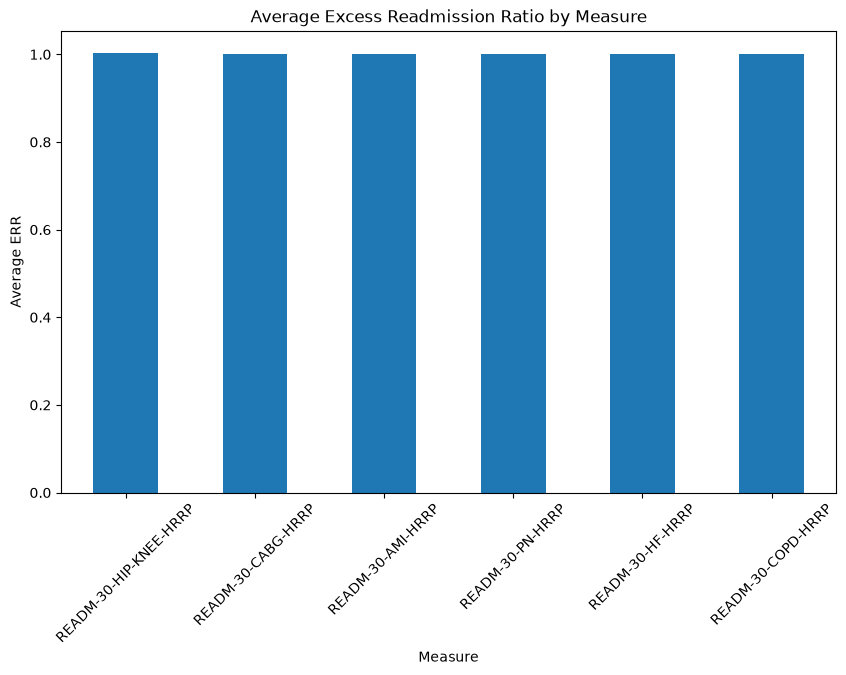

In [17]:
plt.figure(figsize=(10,6))

measure_err.plot(kind='bar')

plt.title('Average Excess Readmission Ratio by Measure')
plt.xlabel('Measure')
plt.ylabel('Average ERR')

plt.xticks(rotation=45)

plt.show()

### Average Excess Readmission Ratio by Measure

This analysis compares average Excess Readmission Ratios across six clinical conditions included in the CMS Hospital Readmissions Reduction Program (HRRP).

Higher ERR values indicate hospitals experienced more readmissions than expected, while values below 1 indicate better-than-expected performance.

Initial findings suggest that readmission performance varies across clinical conditions. Some conditions consistently exhibit higher Excess Readmission Ratios, indicating greater challenges in preventing 30-day readmissions.

### 3rd Chart "Hospital Performance Distribution"

In [18]:
df['performance'] = np.where(
    df['excess_readmission_ratio'] > 1,
    'Worse Than Expected',
    'Better Than Expected'
)

In [19]:
df['performance'].value_counts()

performance
Better Than Expected    12687
Worse Than Expected      5643
Name: count, dtype: int64

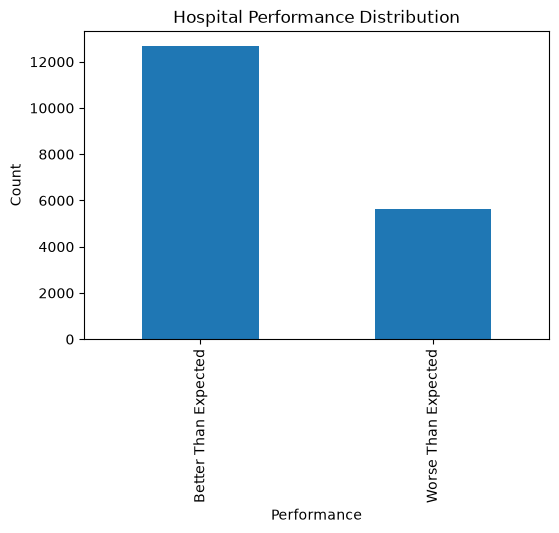

In [20]:
performance_counts = df['performance'].value_counts()

plt.figure(figsize=(6,4))

performance_counts.plot(kind='bar')

plt.title('Hospital Performance Distribution')
plt.xlabel('Performance')
plt.ylabel('Count')

plt.show()

Remarks: Approximately 69% of hospital-condition records achieved readmission performance better than or equal to CMS expectations (ERR ≤ 1), while 31% exceeded expected readmission levels. This suggests that most hospitals were meeting readmission performance targets, although a significant minority may benefit from targeted quality improvement initiatives.

### 4th Chart "Average Excess Readmission Ratio by Measure"

In [21]:
measure_err = (
    df.groupby('measure_name')['excess_readmission_ratio']
      .mean()
      .round(3)
      .sort_values(ascending=False)
)

measure_err

measure_name
READM-30-HIP-KNEE-HRRP    1.004
READM-30-AMI-HRRP         1.002
READM-30-CABG-HRRP        1.002
READM-30-COPD-HRRP        1.001
READM-30-HF-HRRP          1.001
READM-30-PN-HRRP          1.001
Name: excess_readmission_ratio, dtype: float64

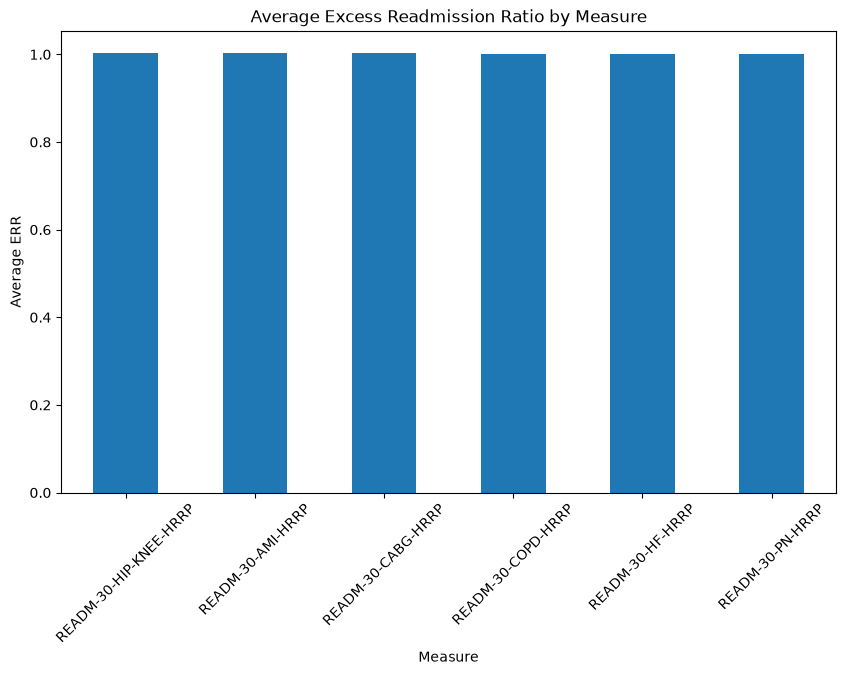

In [22]:
plt.figure(figsize=(10,6))

measure_err.plot(kind='bar')

plt.title('Average Excess Readmission Ratio by Measure')
plt.xlabel('Measure')
plt.ylabel('Average ERR')

plt.xticks(rotation=45)

plt.show()

### 5th Chart "Distribution of ERR"

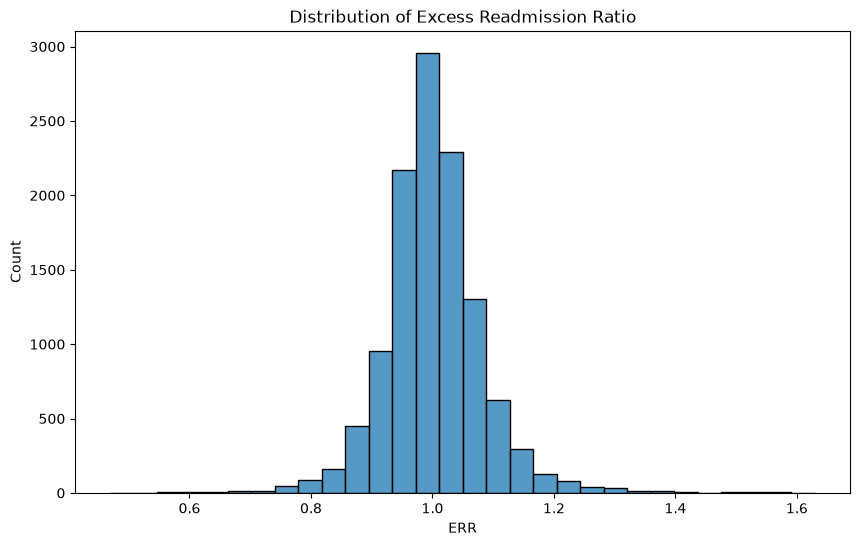

In [23]:
plt.figure(figsize=(10,6))

sns.histplot(
    df['excess_readmission_ratio'],
    bins=30
)

plt.title('Distribution of Excess Readmission Ratio')
plt.xlabel('ERR')

plt.show()

In [24]:
df['excess_readmission_ratio'].describe()

count    11720.000000
mean         1.001777
std          0.082050
min          0.469800
25%          0.958200
50%          0.997300
75%          1.042300
max          1.629700
Name: excess_readmission_ratio, dtype: float64

### Formulate Top 10 Worst Hospitals

In [25]:
worst_hospitals = (
    df.groupby(['facility_name','state'])
      ['excess_readmission_ratio']
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

worst_hospitals

facility_name                                       state
SURGICAL INSTITUTE OF READING                       PA       1.30970
CHRISTUS CENTRAL LOUISIANA SURGICAL HOSPITAL        LA       1.30370
BAYLOR SURGICAL HOSPITAL AT LAS COLINAS             TX       1.28930
MIDWEST ORTHOPEDIC SPECIALTY HOSPITAL               WI       1.26280
ARIZONA ORTHOPEDIC AND SURGICAL SPECIALTY HOSPITAL  AZ       1.25910
METHODIST MCKINNEY HOSPITAL                         TX       1.25510
SIOUX FALLS SPECIALTY HOSPITAL                      SD       1.25160
OROVILLE HOSPITAL                                   CA       1.24836
WINCHESTER HOSPITAL                                 MA       1.22116
ST LUCIE MEDICAL CENTER                             FL       1.20138
Name: excess_readmission_ratio, dtype: float64

### Formulate Top 10 Best Hospitals

In [26]:
best_hospitals = (
    df.groupby(['facility_name','state'])
      ['excess_readmission_ratio']
      .mean()
      .sort_values()
      .head(10)
)

best_hospitals

facility_name                                 state
KANSAS CITY ORTHOPAEDIC INSTITUTE             KS       0.5524
SALINA SURGICAL HOSPITAL                      KS       0.5593
TEXAS ORTHOPEDIC HOSPITAL                     TX       0.5709
NEW ENGLAND BAPTIST HOSPITAL                  MA       0.5939
MCBRIDE ORTHOPEDIC HOSPITAL                   OK       0.6014
BLACK HILLS SURGICAL HOSPITAL LLC             SD       0.6587
ORTHOINDY HOSPITAL                            IN       0.6642
HOSPITAL FOR SPECIAL SURGERY                  NY       0.6738
OSS ORTHOPAEDIC HOSPITAL                      PA       0.6843
MEMORIAL HERMANN HOUSTON PHYSICIANS HOSPITAL  TX       0.6946
Name: excess_readmission_ratio, dtype: float64

### Formulate 10 States with Best Performance

In [27]:
state_err = (
    df.groupby('state')
      .agg(
          avg_err=('excess_readmission_ratio', 'mean'),
          hospitals=('facility_id', 'nunique')
      )
      .reset_index()
)

In [28]:
state_err.head()

,state,avg_err,hospitals
0,AK,0.987117,8
1,AL,1.013884,77
2,AR,1.000306,43
3,AZ,1.000878,64
4,CA,1.010077,277


In [29]:
# Avoid outlier:
state_err_filtered = state_err[
    state_err['hospitals'] >= 20
]

In [30]:
best_states = (
    state_err_filtered
      .sort_values('avg_err')
      .head(10)
)

best_states

,state,avg_err,hospitals
44,UT,0.955931,32
37,OR,0.959863,32
47,WA,0.963568,46
16,KS,0.966171,44
5,CO,0.967389,51
12,IA,0.971617,30
23,MN,0.977826,46
29,NE,0.978696,25
48,WI,0.982044,65
32,NM,0.983886,26


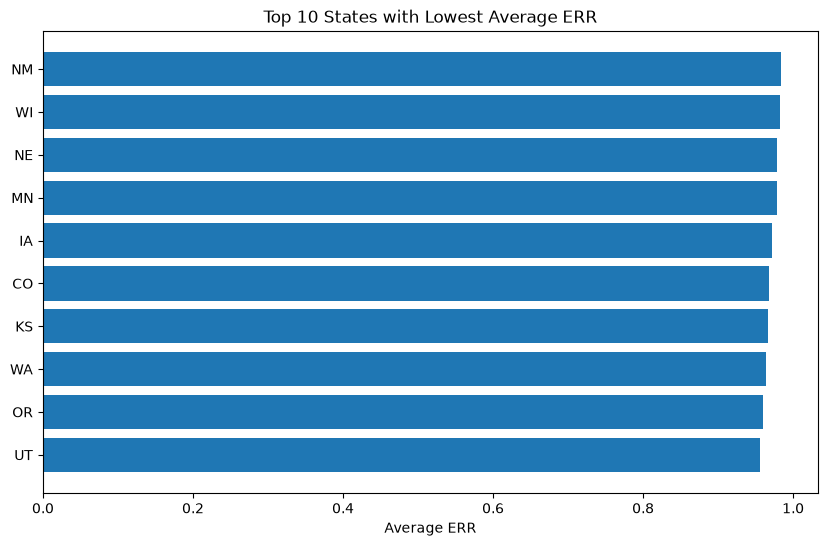

In [31]:
plt.figure(figsize=(10,6))

plt.barh(
    best_states['state'],
    best_states['avg_err']
)

plt.title('Top 10 States with Lowest Average ERR')
plt.xlabel('Average ERR')

plt.show()

### Formulate Top 10 Worst States

In [32]:
worst_states = (
    state_err_filtered
      .sort_values('avg_err', ascending=False)
      .head(10)
)

worst_states

,state,avg_err,hospitals
19,MA,1.034428,55
31,NJ,1.027668,61
9,FL,1.022866,169
14,IL,1.019390,114
25,MS,1.014094,59
1,AL,1.013884,77
49,WV,1.011502,25
33,NV,1.011438,22
10,GA,1.011403,94
17,KY,1.010135,59


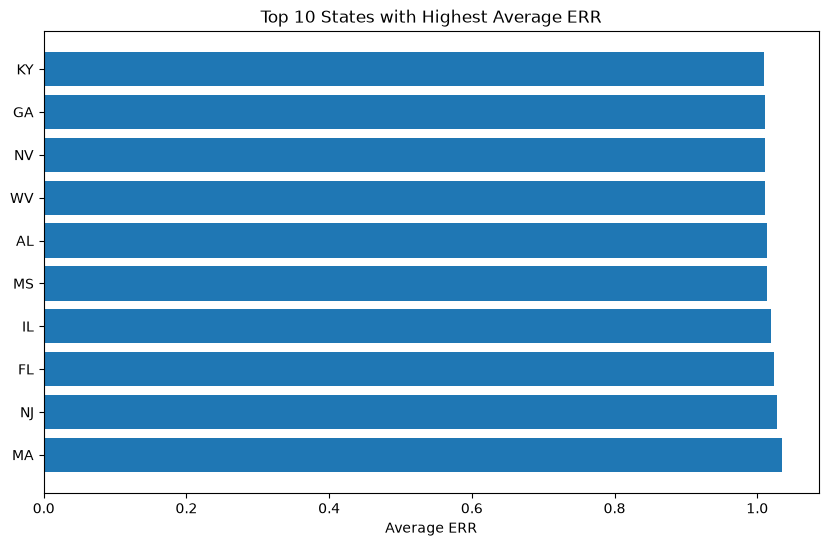

In [33]:
plt.figure(figsize=(10,6))

plt.barh(
    worst_states['state'],
    worst_states['avg_err']
)

plt.title('Top 10 States with Highest Average ERR')
plt.xlabel('Average ERR')

plt.show()

### Remarks on State-Level Performance

Substantial variation exists across states.

Utah, Oregon, and Washington demonstrated the lowest average Excess Readmission Ratios, indicating better-than-expected performance.

In contrast, Massachusetts, New Jersey, and Florida exhibited the highest average ERR values, suggesting greater challenges in reducing 30-day readmissions.

## KPI Summary

In [34]:
# Create cell:
total_records = len(df)

better_than_expected = (
    df['excess_readmission_ratio'] <= 1
).sum()

worse_than_expected = (
    df['excess_readmission_ratio'] > 1
).sum()

avg_err = df['excess_readmission_ratio'].mean()

print(f'Total Records: {total_records:,}')
print(f'Better Than Expected: {better_than_expected:,}')
print(f'Worse Than Expected: {worse_than_expected:,}')
print(f'Average ERR: {avg_err:.3f}')

Total Records: 18,330
Better Than Expected: 6,077
Worse Than Expected: 5,643
Average ERR: 1.002


# Key Findings

1. Approximately 69% of hospital-condition records achieved readmission performance at or below CMS expectations.

2. Excess Readmission Ratios varied substantially across hospitals, indicating significant differences in readmission performance.

3. State-level variation was observed, with Utah, Oregon, and Washington achieving the strongest performance.

4. Massachusetts, New Jersey, and Florida demonstrated the highest average readmission ratios among states with sufficient hospital representation.

5. These findings suggest opportunities for targeted quality improvement efforts in regions and facilities with consistently elevated readmission rates.

## Create dataset for use with Tableau

In [35]:
# 1. Main Dataset for Tableau
df.to_csv(
    '../outputs/hospital_readmissions_clean.csv',
    index=False
)

In [36]:
# 2. Best States
best_states.to_csv(
    '../outputs/best_states.csv',
    index=False
)

In [37]:
# 3. Worst States
worst_states.to_csv(
    '../outputs/worst_states.csv',
    index=False
)

In [38]:
# 4. Best Hospitals
best_hospitals = (
    df.groupby(['facility_name','state'])
      ['excess_readmission_ratio']
      .mean()
      .reset_index()
      .sort_values('excess_readmission_ratio')
      .head(10)
)

best_hospitals

best_hospitals.to_csv(
    '../outputs/best_hospitals.csv',
    index=False
)

In [39]:
# 5. Worst Hospitals
worst_hospitals = (
    df.groupby(['facility_name','state'])
      ['excess_readmission_ratio']
      .mean()
      .reset_index()
      .sort_values(
          'excess_readmission_ratio',
          ascending=False
      )
      .head(10)
)

worst_hospitals
worst_hospitals.to_csv(
    '../outputs/worst_hospitals.csv',
    index=False
)